# Classificação de flores Iris com MLP

Este notebook demonstra a criação de uma rede neural simples para classificar espécies de flores Iris utilizando a biblioteca TensorFlow/Keras.

O nosso objetivo é criar uma rede neural para classificação automática do tipo de flor Iris dado como entrada o comprimento e largura da sépala, comprimento e largura da pétala.

A rede deve dizer se trata-se de uma flor: iris setosa, iris versicolor, iris virginica.

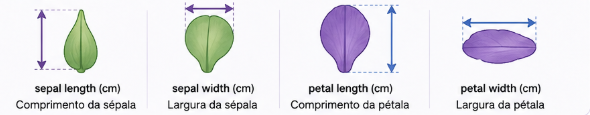

### 1. Preparação dos Dados
Nesta etapa, carregamos o dataset Iris e preparamos os dados para a rede neural.

In [ ]:
!pip install shap

In [ ]:
!pip install lime


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay
import shap
import lime
from lime import lime_tabular

iris = load_iris()
caracteristicas = iris.data
especies = iris.target

display(pd.DataFrame(caracteristicas, columns=iris.feature_names).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 1.1 Distribuição dos dados

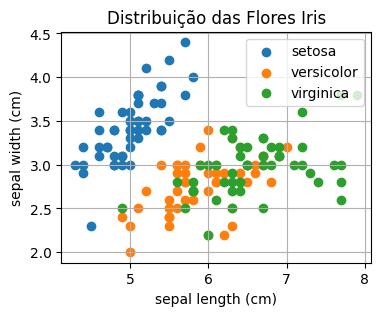

In [4]:
plt.figure(figsize=(4, 3))
for i, nome_alvo in enumerate(iris.target_names):
    plt.scatter(caracteristicas[especies == i, 0], caracteristicas[especies == i, 1], label=nome_alvo)

plt.title("Distribuição das Flores Iris")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.grid(True)
plt.show()

### 1.3 Transformar espécies em formato numérico binário (One-Hot Encoding)

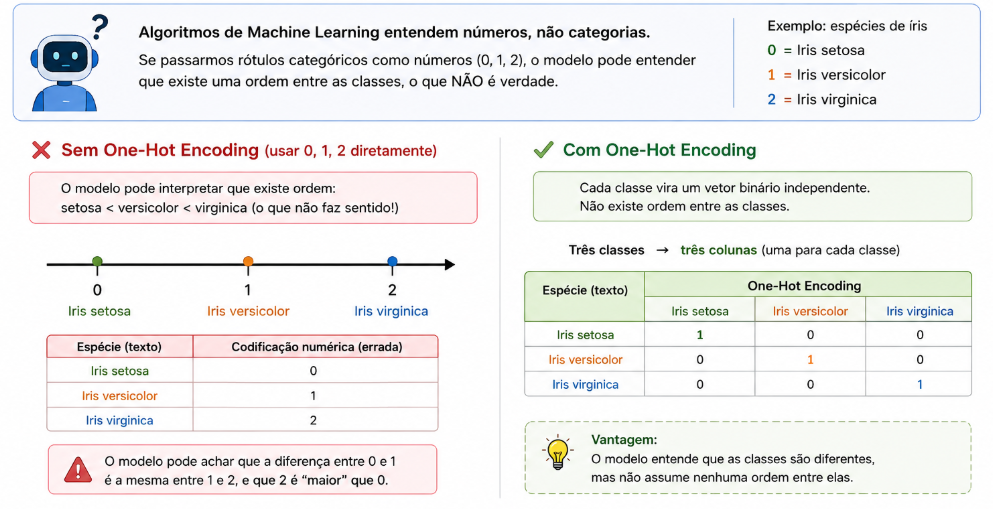

In [5]:
encoder = OneHotEncoder(sparse_output=False)
especies_encoded = encoder.fit_transform(especies.reshape(-1, 1))

print("Exemplo de espécies codificadas:")
print(especies_encoded[:5])

Exemplo de espécies codificadas:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### 1.4 Dividir em treino (80%) e teste (20%)

In [6]:
caract_treino, caract_teste, esp_treino, esp_teste = train_test_split(
    caracteristicas, especies_encoded, test_size=0.2, random_state=42
)

### 1.5 Normalizar os dados

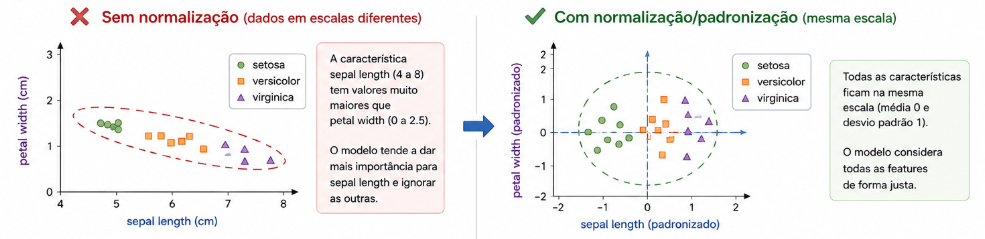

In [7]:
padronizador = StandardScaler()
caract_treino = padronizador.fit_transform(caract_treino)
caract_teste = padronizador.transform(caract_teste)

### 2. Construção e Treinamento da MLP
Agora definimos a estrutura da rede neural e realizamos o treinamento.

In [8]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])



In [ ]:

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['mse'])


historico = model.fit(caract_treino, esp_treino, epochs=100, batch_size=5, validation_split=0.1)


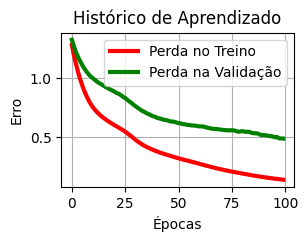

In [10]:
plt.figure(figsize=(3,2))
plt.plot(historico.history['loss'], label='Perda no Treino', color='red', linewidth=3)
plt.plot(historico.history['val_loss'], label='Perda na Validação', color='green', linewidth=3)
plt.title('Histórico de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
model.save('modelo.keras')

In [12]:
perda, erro = model.evaluate(caract_teste, esp_teste, verbose=0)
print(f"Erro MSE final no teste: {erro*100:.2f}%")

Erro MSE final no teste: 2.03%


In [13]:
previsoes_prob = model.predict(caract_teste)

classes_preditas = np.argmax(previsoes_prob, axis=1)
classes_reais = np.argmax(esp_teste, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [14]:
print(classification_report(classes_reais, classes_preditas, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



<Figure size 500x400 with 0 Axes>

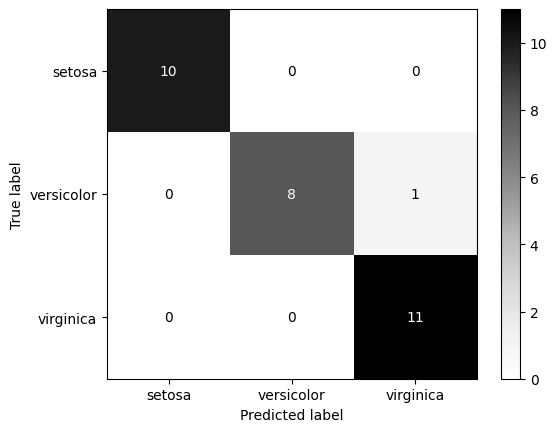

In [15]:
matriz_confusao = confusion_matrix(classes_reais, classes_preditas)

plt.figure(figsize=(5,4))
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=iris.target_names)
display_matriz.plot(cmap='Greys', values_format='d')

# SHAP (SHapley Additive exPlanations) & IA Explicável (XAI)

### O que é IA Explicável (XAI)?
À medida que os modelos de Machine Learning (especialmente redes neurais profundas e modelos de boosting) tornam-se mais complexos, eles passam a funcionar como uma **"caixa preta"** (*black box*). Embora apresentem alta acurácia nas previsões, torna-se extremamente difícil compreender *por que* tomaram determinada decisão.

A **Inteligência Artificial Explicável (XAI - Explainable AI)** é uma subárea da IA focada em criar métodos e técnicas que tornem os resultados dos modelos de aprendizado de máquina compreensíveis para os seres humanos. Isso é crucial para:
- **Confiança e Transparência:** Validar se o modelo não está tomando decisões com base em vieses ou correlações espúrias.
- **Conformidade de Negócio e Regulamentações:** Setores sensíveis como saúde, finanças e direito exigem justificativas para tomadas de decisão automáticas.
- **Depuração (Debugging):** Ajudar desenvolvedores e cientistas de dados a entender onde e por que o modelo falha.

---

### O que é o SHAP?
O **SHAP (SHapley Additive exPlanations)** é um dos frameworks de explicabilidade mais robustos e populares da atualidade. Ele é baseado na **Teoria dos Jogos Cooperativos**, especificamente nos **Valores de Shapley** (propostos por Lloyd Shapley, vencedor do Prêmio Nobel de Economia).

#### Como funciona na prática?
Imagine que a previsão do modelo é o "resultado de um jogo" e cada característica de entrada (como o comprimento da pétala ou a largura da sépala) é um "jogador". O valor SHAP mede a contribuição marginal que cada característica trouxe para o resultado final em relação à previsão média do dataset (chamada de *base value*).

#### Principais Propriedades do SHAP:
1. **Consistência (Consistency):** Se um modelo mudar de forma que uma característica tenha mais impacto no resultado, o valor SHAP atribuído a ela nunca diminuirá.
2. **Aditividade local (Local Accuracy):** A soma dos valores SHAP de todas as características para uma amostra específica será sempre igual à diferença entre a previsão do modelo para aquela amostra e a previsão média do modelo para todo o dataset.
3. **Explicabilidade Global e Local:**
   - **Local:** Explica individualmente o motivo de uma única previsão (por exemplo, por que a flor #10 foi classificada como *versicolor* por meio de gráficos como o *Force Plot* ou *Bar Plot*).
   - **Global:** Analisa o impacto geral e a importância de cada variável ao longo de todo o conjunto de dados por meio do *Summary Plot*.

In [16]:
explainer = shap.KernelExplainer(model.predict, caract_teste[:50])

shap_values = explainer.shap_values(caract_teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


  0%|          | 0/30 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━

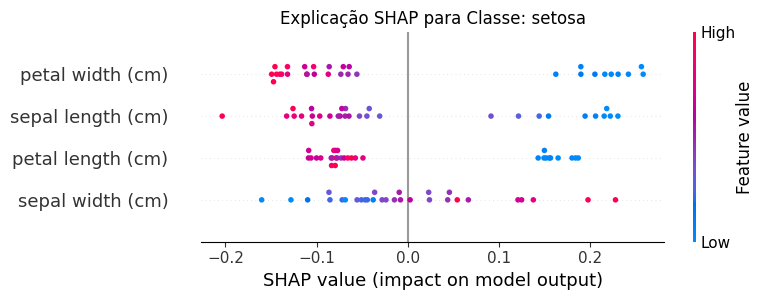

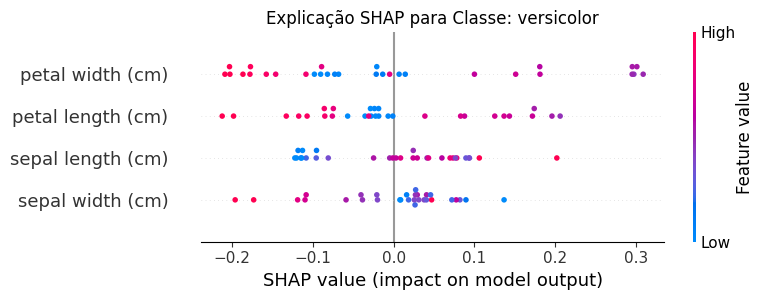

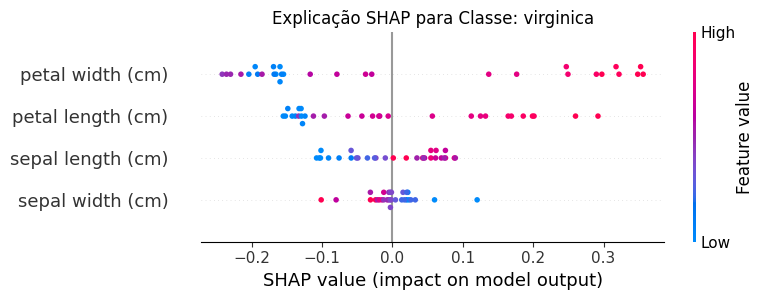

In [17]:
class_names = list(iris.target_names)

for i, class_name in enumerate(class_names):
  plt.figure(figsize=(6,3))
  plt.title(f"Explicação SHAP para Classe: {class_name}")
  shap_val_class = shap_values[:, :, i]

  shap.summary_plot(shap_val_class, caract_teste, feature_names=iris.feature_names)
  plt.show()

### Como interpretar o `summary_plot` do SHAP?

O gráfico de resumo (`summary_plot`) combina a importância das variáveis com os seus efeitos sobre o resultado do modelo. Cada ponto no gráfico representa o valor SHAP de uma característica para uma única amostra (flor) do conjunto de teste.

Para ler o gráfico, analise os seguintes elementos:

1. **Ordenação das Variáveis (Eixo Y):**
   - As variáveis estão ordenadas de cima para baixo de acordo com o seu impacto global no modelo. A variável no topo é a mais importante para prever a classe em questão.

2. **Impacto na Previsão (Eixo X):**
   - O eixo horizontal mostra o valor SHAP.
   - Pontos à **direita do zero** (valores SHAP positivos) indicam que a característica contribuiu para **aumentar** a probabilidade de a flor pertencer àquela classe específica.
   - Pontos à **esquerda do zero** (valores SHAP negativos) indicam que a característica contribuiu para **diminuir** a probabilidade de pertencer àquela classe.

3. **Valor da Característica (Escala de Cores à Direita):**
   - A cor de cada ponto indica se o valor original daquela característica era alto ou baixo na amostra.
   - **Vermelho (High):** Indica valores altos para a característica (ex: pétalas longas/largas).
   - **Azul (Low):** Indica valores baixos para a característica (ex: pétalas curtas/estreitas).

#### Exemplo Prático com a classe **Setosa**:
- Olhando para o gráfico da classe *setosa*, vemos que pontos azuis (valores baixos) de `petal length (cm)` e `petal width (cm)` estão concentrados fortemente à direita do zero.
- **Conclusão:** Valores baixos de comprimento e largura de pétala são o principal fator que faz o modelo classificar uma flor como *setosa*.

In [18]:
shap.initjs()

amostra = 10
base_value_setosa = explainer.expected_value[0]
shap_val_setosa_amostra = shap_values[amostra, :, 0]

<Figure size 1000x300 with 0 Axes>

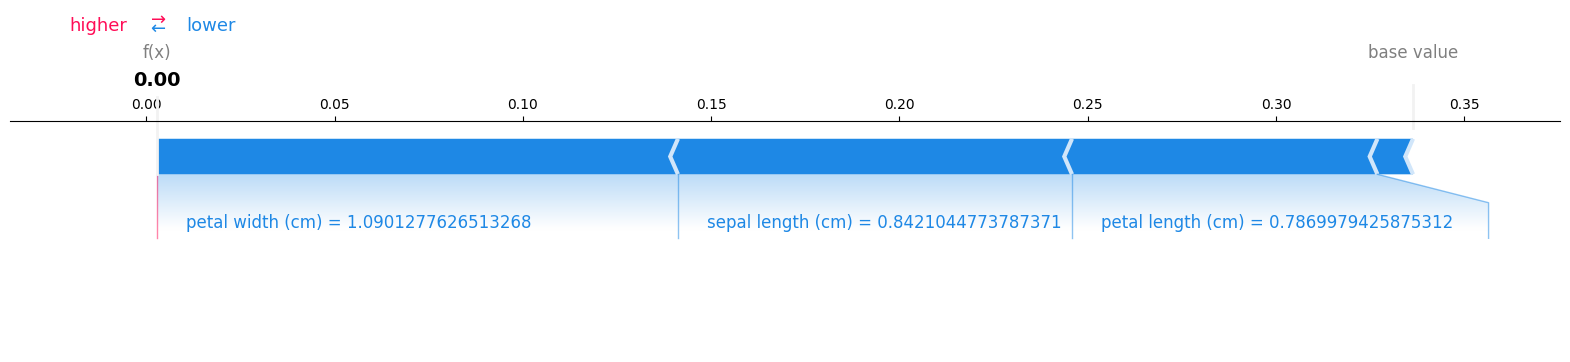

In [19]:
plt.figure(figsize=(10,3))
shap.force_plot(
    base_value_setosa,
    shap_val_setosa_amostra,
    caract_teste[amostra],
    feature_names = iris.feature_names,
    matplotlib=True
)
plt.show()

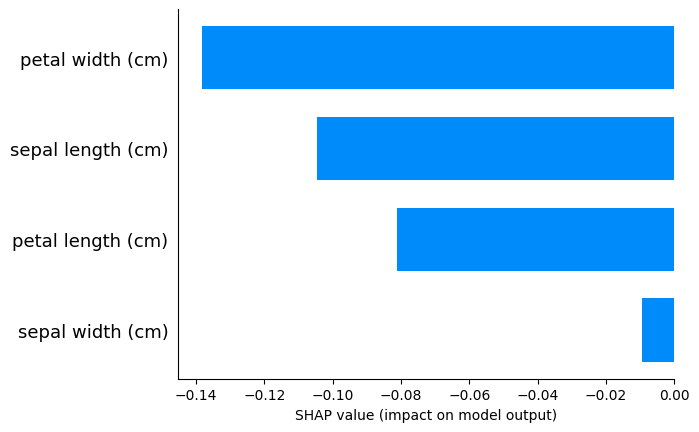

In [20]:
shap.bar_plot(shap_val_setosa_amostra, feature_names=iris.feature_names)

## LIME (Local Interpretable Model-agnostic Explanations)

### O que é o LIME?
O **LIME** é um método de Inteligência Artificial Explicável (XAI) proposto para explicar as previsões de **qualquer** classificador ou regressor de aprendizado de máquina (por isso é chamado de *model-agnostic*, ou agnóstico ao modelo).

Diferente do SHAP, que tenta calcular a contribuição exata e global de cada variável usando teoria dos jogos, o foco do LIME é estritamente **local**.

### Como o LIME funciona?
O princípio fundamental do LIME é que, embora um modelo de aprendizado de máquina possa ser extremamente complexo globalmente (uma fronteira de decisão altamente não-linear e cheia de curvas), se dermos um zoom e olharmos apenas para os **arredores de uma única previsão (uma instância específica)**, a decisão do modelo pode ser aproximada por um modelo interpretável simples (como uma regressão linear simples ou uma árvore de decisão).

O processo do LIME para explicar uma única previsão consiste em:
1. **Perturbação dos dados:** O LIME cria um novo conjunto de dados sintéticos ao redor da amostra original que queremos explicar (adicionando pequenos ruídos ou variações às suas características).
2. **Obtenção de previsões:** O LIME passa essas amostras perturbadas pelo nosso modelo "caixa-preta" (a rede neural MLP, por exemplo) para obter as previsões correspondentes.
3. **Ponderação por proximidade:** O algoritmo atribui um peso maior para as amostras sintéticas que estão mais próximas da amostra original.
4. **Treinamento de um modelo substituto simples:** Um modelo linear simples (fácil de interpretar) é treinado usando esses dados perturbados ponderados para aprender como o modelo complexo se comporta naquela vizinhança específica.
5. **Interpretação:** Os coeficientes desse modelo linear simples são usados para explicar a importância e o impacto de cada característica para aquela decisão local específica.

In [21]:
def predict_fn(x):
    x_scaled = padronizador.transform(x)
    return model.predict(x_scaled, verbose=0)

caract_treino_original = padronizador.inverse_transform(caract_treino)

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=caract_treino_original,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
    mode='classification'
)



In [22]:
amostra_original = padronizador.inverse_transform(caract_teste[amostra].reshape(1, -1))[0]

exp = explainer_lime.explain_instance(
    data_row=amostra_original,
    predict_fn=predict_fn,
    num_features=4,
    labels=(0, 1, 2)
)

exp.show_in_notebook(show_table=True)